**<font color=skyblue>PCA 與 SVD 在影像處理的應用（二）</font>**

- 關於數字影像資料的壓縮與儲存：資料矩陣含多張影像
- 參考講義：https://ntpuccw.blog/python-in-learning/sml%e6%b7%ba%e5%ba%a6%e6%a9%9f%e5%99%a8%e5%ad%b8%e7%bf%92%ef%bc%9apca-%e3%80%81svd-%e5%8f%8a%e5%85%b6%e5%9c%a8%e5%bd%b1%e5%83%8f%e8%99%95%e7%90%86%e7%9a%84%e6%87%89%e7%94%a8/

<font color=yellow>Import libraries</font>

In [2]:
# import os
# import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import io
from numpy.linalg import svd
from sklearn.decomposition import PCA
# from sklearn.datasets import fetch_openml
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

<font color=yellow>Download data</font>
- Check if data exists in the local directory
- If not, download from sklearn.datasets for the first time.
- Save the data as pkl file in the local directory.
- If yes, open from the local directory.
- Observe the data structure and data

In [3]:
from sklearn.datasets import fetch_openml
import pickle
import os

data_file = 'data/mnist_digits_784.pkl'
# Check if data file exists
if os.path.isfile(data_file):
    # Load data from file
    with open(data_file, 'rb') as f:
        data = pickle.load(f)
else:
    # Fetch data from internet sklearn.datasets.fetch_openml
    data = fetch_openml('mnist_784', version=1, parser='auto')
    # Save data to file
    with open(data_file, 'wb') as f:
        pickle.dump(data, f)
# Print the keys
print(data.keys())
# Print the shape of the data
print(data.data.shape)
print(data.target.shape)

# description of the data
print(data.DESCR)

# Print the unique labels
print(np.unique(data.target))
# Print the first few data points
# print(data.data[:5])
# Extract data and labels
X, y = np.array(data.data).T, np.array(data.target).astype('int')

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(70000, 784)
(70000,)
**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain 

<font color=yellow> Define a montage matrix</font>

下面的蒙太奇圖函數用來處理特殊影像矩陣 A，其中每一行向量代表經過 reshape 的一張圖，而行數代表矩陣所儲存的圖形數量。

In [4]:
# ---------------------------------------
def montage(A, m, n):
    '''
    Create a montage matrix with mn images
    Inputs:
    A: original pxN image matrix with N images (each has p pixels), N > mn
    m, n: m rows & n columns, total mn images
    Output:
    M: montage matrix containing mn images
    '''
    
    sz = np.sqrt(A.shape[0]).astype('int') # image size sz x sz
    M = np.zeros((m*sz, n*sz)) # montage image
    
    for i in range(m) :
        for j in range(n) :
            M[i*sz: (i+1)*sz, j*sz:(j+1)*sz] = \
                A[:, i*n+j].reshape(sz, sz)

    return M

下面的蒙太奇圖函數是另一個版本，寫法更精煉些，只用一個迴圈。

In [5]:
def montage_v2(A, m, n):
# by 李晏丞
# 讀取所有圖片並串聯成montage
    sz = np.sqrt(A.shape[0]).astype("int")
    M = np.zeros((sz*m, sz*n))

    for i in range(m*n):
        # 找出新舊矩陣的關係
        row = (i // n) * sz # // 代表整數除法
        col = (i % n) * sz # % 代表取餘數
        M[row:row+sz, col:col+sz] = A[:, i].reshape(sz, sz)
    return M

下面的蒙太奇版本取自 skimage 的 montage 函數，使用了 skimage 的 view_as_blocks 函數來實現蒙太奇圖的生成。

In [6]:
from skimage.util import montage as sk_montage

def montage_pkg(A, m, n):
    sz = int(np.sqrt(A.shape[0]))
    imgs = A.T.reshape(-1, sz, sz)          # (N, H, W)
    M = sk_montage(
        imgs[:m*n],
        grid_shape=(m, n),
        padding_width=0,
        fill=0
    )
    return M

<font color=yellow>測試資料</font>：從資料矩陣準確地提出圖片

- 可以任選一行，如下列程式碼所示
- 也可以任挑一個數字圖形，寫寫看。

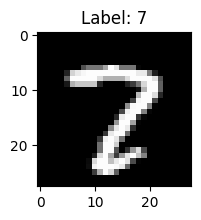

In [7]:
i = 12000
img = X[:, i] # image vector
sz = np.sqrt(len(img)).astype('int') # image size sz x sz
fig = plt.figure(figsize=(2, 2))
plt.imshow(img.reshape(sz, sz), cmap='gray')
plt.title(f"Label: {y[i]}")
plt.show()

<font color=skyblue>Demonstare a montage image (1)</font>

以蒙太奇圖的方式呈現多張數字圖形

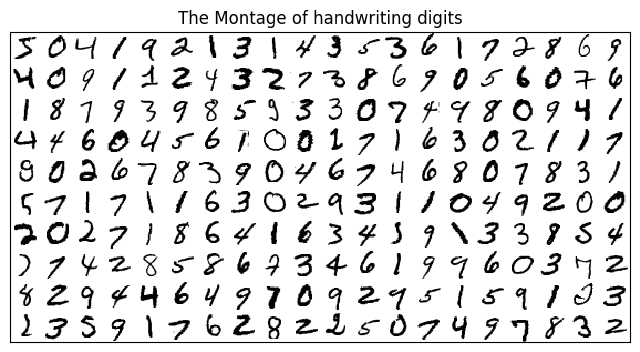

In [8]:
plt.figure(figsize = (8, 6))
m, n = 10, 20  # A m x n montage (total mn images)
# Arrange images to form a montage  
M = montage_pkg(X, m, n)
# M = montage_v2(X, m, n)
plt.imshow(M, cmap = plt.cm.gray_r, interpolation = 'nearest') # gray_r: reverse gray colormap
plt.xticks([])
plt.yticks([])
plt.title('The Montage of handwriting digits')
plt.show()

任選一數字並抽取若干張，以蒙太奇圖方式呈現

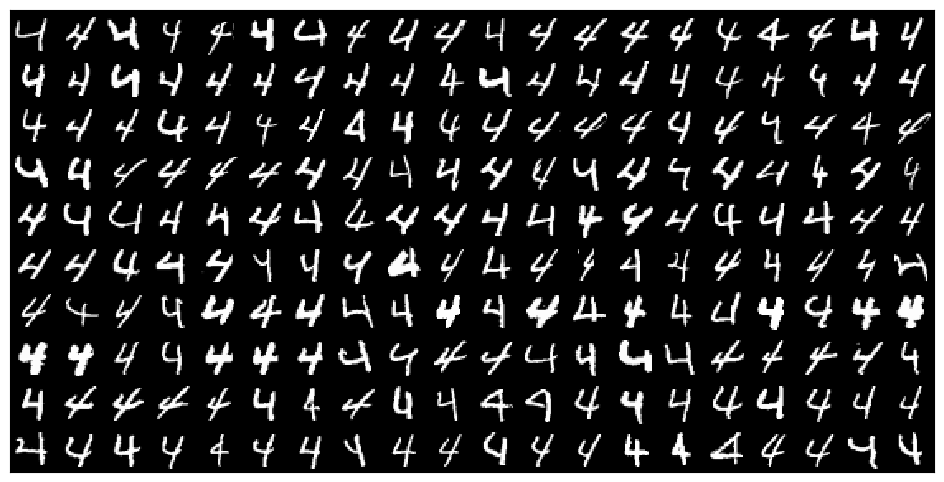

Digit  4 : 6824 張


In [9]:
digit_to_show = 4
Digit = X[:, y==digit_to_show]
plt.figure(figsize = (12, 6))
m, n = 10, 20  # A m x n montage (total mn images)
M = montage(Digit, m, n)
plt.imshow(M, cmap = 'gray', interpolation = 'nearest') # gray: normal gray colormap
# plt.imshow(M, cmap = plt.cm.gray_r, interpolation = 'nearest') # gray_r: reverse gray colormap
plt.xticks([])
plt.yticks([])
plt.show()
print('Digit ', digit_to_show, ':', sum(y==digit_to_show), '張') # count how many images have the same label as the i-th image


<font color=yellow>觀察資料矩陣裡的每個數字</font>

- 採隨機方式每次秀出 50 個 0~9 的數字
- 看看數字在圖片的樣子、清晰度、、、等。
- 每次執行都隨機挑選

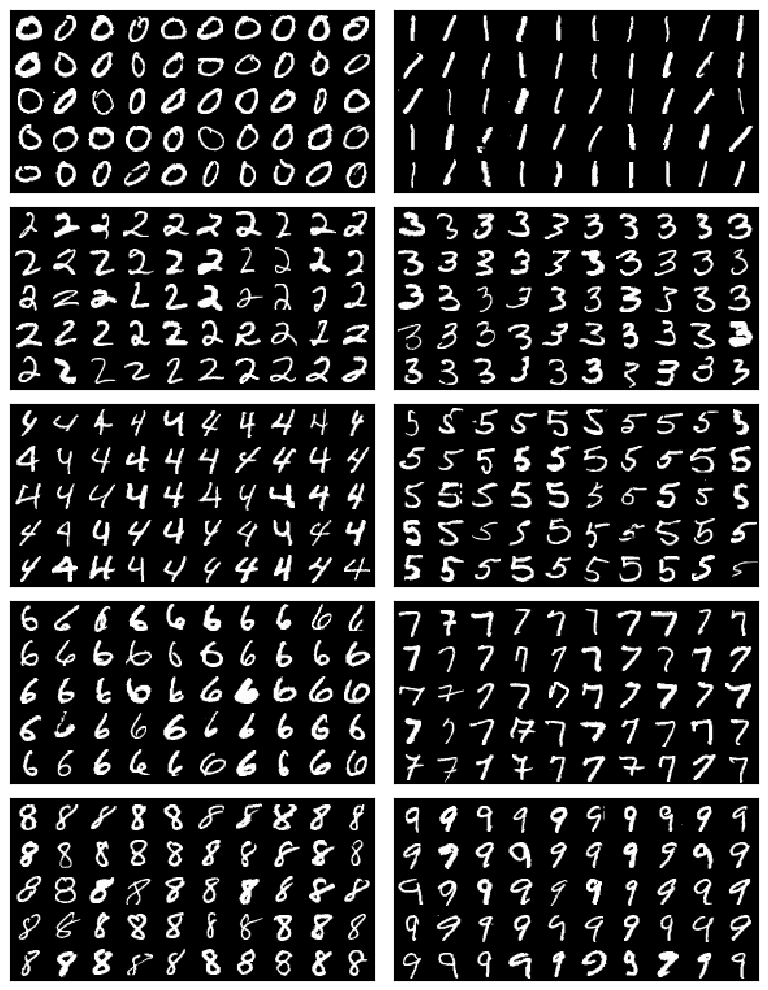

In [10]:
N = 50
digit_to_show = np.arange(10)
fig, axes = plt.subplots(5, 2, figsize=(8, 10))

for i, ax in enumerate(axes.flat):
    Digit = X[:, y==digit_to_show[i]]
    idx = np.random.choice(np.arange(Digit.shape[1]), replace=False, size=N)
    ax.imshow(montage(Digit[:, idx], 5, 10), cmap = 'gray', interpolation = 'nearest')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

<font color=yellow>Do rank q approximation by PCA</font>

- 矩陣的每一行代表一張 28x28 的圖，向量長度為 784 
- 將每個數字的每一個像素當作一個變數，共有 784 個變數。
- 將每個數字的數量當作樣本數
- 對每個數字的所有樣本矩陣 $D$ 進行 PCA 分析，取前 $q$ 個主成分 $Z_q$，再重組回 $D_q$。
- 注意：PCA 指令對資料結構的要求是 (samples, features)，對照此處的數字矩陣，方向剛好相反，因此必須先將數字矩陣轉置，再送入 PCA。

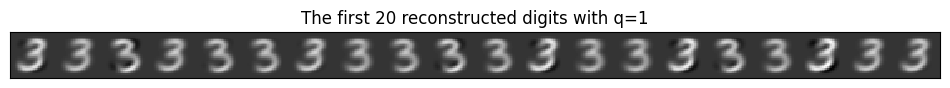

In [10]:
digit_to_show = 3 # Select the digit to show
D = X[:, y==digit_to_show].T # Transpose the data matrix to have samples as rows and features as columns
q = 1
pca = PCA(n_components=q)
pca.fit(D)
Z = pca.transform(D) # projection of the original data onto the q principal components
D_q = pca.inverse_transform(Z) # reconstruction of the original data
# print(D_q.shape)

plt.figure(figsize = (12, 6))
m, n = 1, 20  # A m x n montage (total mn images)
M = montage(D_q.T, m, n) # Transpose back to have features as rows and samples as columns for montage
plt.imshow(M, cmap = 'gray', interpolation = 'nearest')
plt.xticks([])
plt.yticks([])
plt.title('The first %d reconstructed digits with q=%d' % (n, q))
plt.show()

<font color=yellow>Do rank q approximation with q <= 30</font>

- 注意: 此處 D_q 必須加上均值。可以試試不加均值的結果。
- 第 1 列呈現原始圖片。
- 第 2 列開始呈現 PCA 轉換後再重塑的圖形，依 $q = 1,3,5\cdots, n$ 往下排列。
- 請留意下列程式碼使用的 PCA 轉置與重塑圖形的方式與前面的示範程式不同。也可以嘗試用不同的寫法來達到相同的目的。即 $q$ 愈大，重塑的圖形愈清晰，愈接近第一列的原圖。
- 可以嘗試在最左邊或最右邊加一欄呈現 $q$ 值，以方便觀察 $q$ 值的影響。

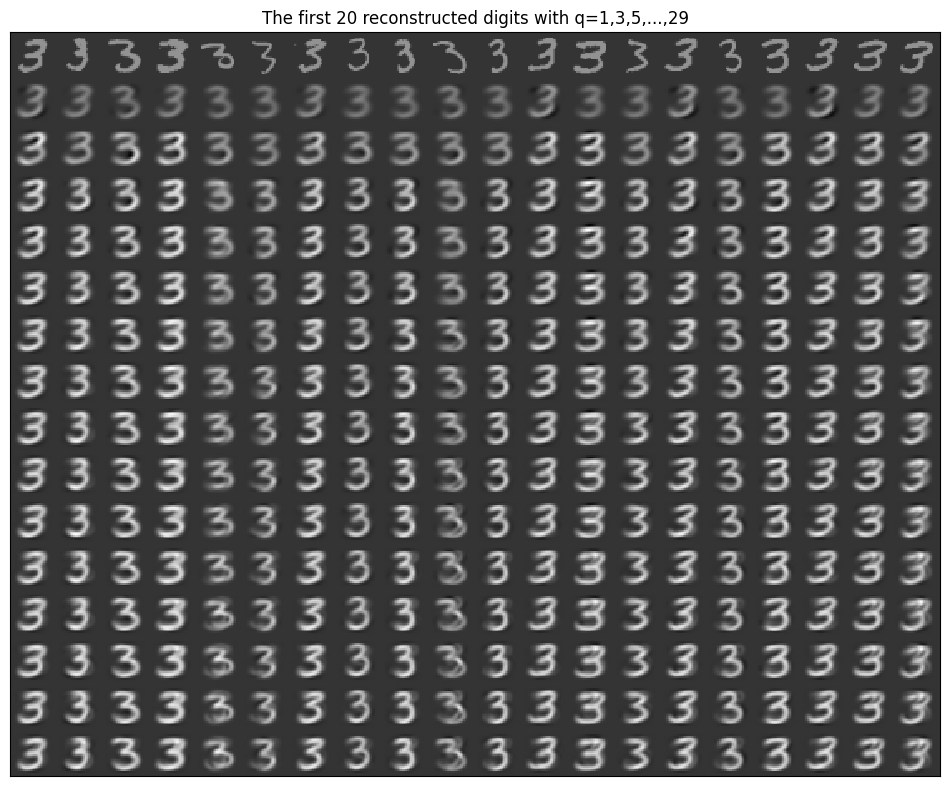

In [11]:
q = 30 # number of principal components
n = 20 # number of digits to show
digit_to_show = 3
D = X[:, y==digit_to_show].T # Transpose the data matrix to have samples as rows and features as columns
pca = PCA(n_components=q)
pca.fit(D)
eigenvectors = pca.components_.T # get eigenvectors and eigenvalues

M = D[:n, :].T # take the first 20 digits as the first row of the montage
q_selected = np.arange(1, q+1, 2) # select the number of principal components to use for reconstruction, e.g., q=1,3,5,...,29
m = len(q_selected) # number of montages
for i in q_selected:
    U = eigenvectors[:, :i]
    Z = U.T @ D.T # Z is the PCA representation of the data
    # reconstruct the data using the first i eigenvectors
    D_q = U @ Z + pca.mean_[:, np.newaxis] # note that we need to add the mean back to the data
    M = np.c_[M, D_q[:, :n]]

plt.figure(figsize = (12, 12))
plt.imshow(montage(M, m+1, n), cmap = 'gray', interpolation = 'nearest')
plt.xticks([])
plt.yticks([])
plt.title('The first %d reconstructed digits with q=1,3,5,...,%d' % (n, i))
plt.show()

<font color=yellow>Do Rank q approximation by SVD</font>

$$X_q = \sum_{k=1}^{q} \sigma_k\underline{u}_k\underline{v}^T_k = U_q\Sigma_q V^T_q = U_qU_q^TX$$

注意：使用 svd 指令時，同樣要注意該指令對資料矩陣的結構要求。


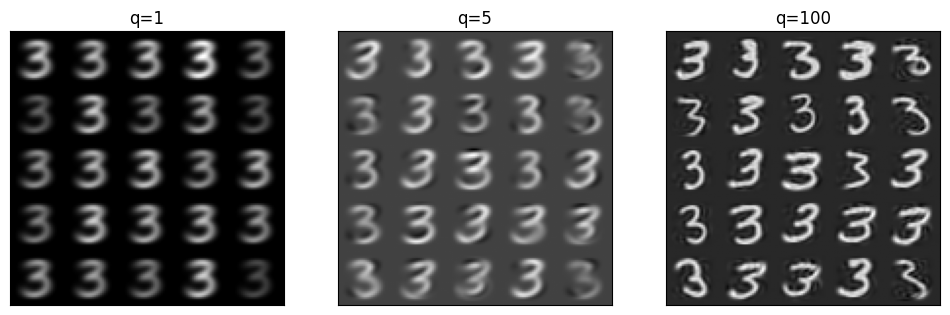

In [12]:
digit_to_show = 3
D = X[:, y==digit_to_show]
U, E, VT = svd(D, full_matrices = False)
q = np.array([1, 5, 100])
m, n = 5, 5
fig, ax = plt.subplots(1, len(q), figsize=(12, 4))
for i, r in enumerate(q):
    Xq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :] # Xq = UqEqVqT
    # Xq = U[:, :r] @ (U[:, :r].T @ D[:, :m*n]) # Xq = UqUq^TX
    ax[i].imshow(montage(Xq, m, n), cmap = 'gray')
    # ratio = N * p / (U.shape[0] + VT.shape[1]) / r
    ax[i].set_title('q={}'.format(r))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.show()

觀察 SVD 前 q 個項的和，呈現方式同上

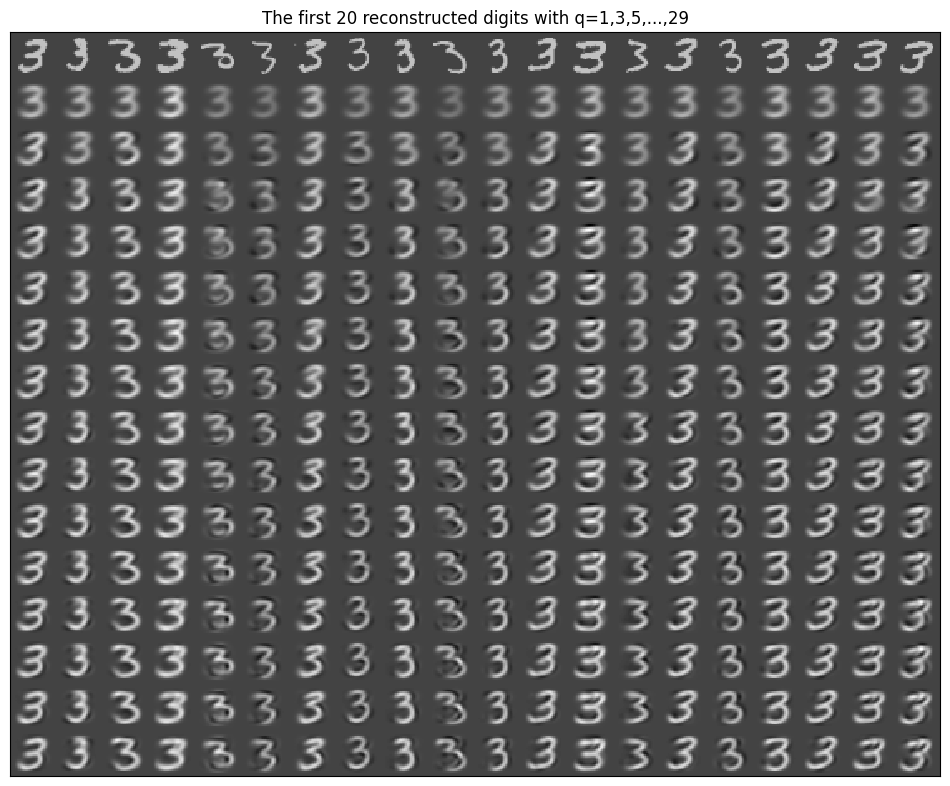

In [15]:
N = 20
digit_to_show = 3
D = X[:, y==digit_to_show]
M = np.array(D)[:, 0:N]
q = np.arange(1, 31, 2)
U, E, VT = svd(D, full_matrices = False)
for i, r in enumerate(q):
    Xq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :]
    M = np.c_[M, Xq[:, :N]]
plt.figure(figsize = (12, 12))
plt.imshow(montage(M, len(q)+1, N), cmap = 'gray', interpolation = 'nearest')
plt.xticks([])
plt.yticks([])
plt.title('The first %d reconstructed digits with q=1,3,5,...,%d' % (N, q[-1]))
plt.show()

$$A = \sum_{k=1}^{r} \sigma_k \underline{u}_k \underline{v}_k^T=\sigma_1 \underline{u}_1 \underline{v}_1^T+\sigma_2 \underline{u}_2 \underline{v}_2^T+\cdots+\sigma_r \underline{u}_r \underline{v}_r^T$$

觀察 SVD 分解的前幾個成分的個別長相，其中 $\sigma_k$ 是一個數字，$\underline{u}_k$ 是一個行向量，$\underline{v}_k^T$ 是一個列向量。將 $\sigma_k\underline{u}_k\underline{v}_k^T$ 取前 20 行，重塑成 28x28 的圖形，看看它的樣子。可以觀察到 $\sigma_k$ 的大小對圖形的影響，以及 $\underline{u}_k$ 和 $\underline{v}_k^T$ 的結構對圖形的影響。

注意：程式產生的圖，第一列為原圖，第二列開始為 $k=1,2,3\cdots$ 的圖形，依序往下排列。可以在最左邊或最右邊加一欄呈現 $k$ 值，以方便觀察 $k$ 值的影響。

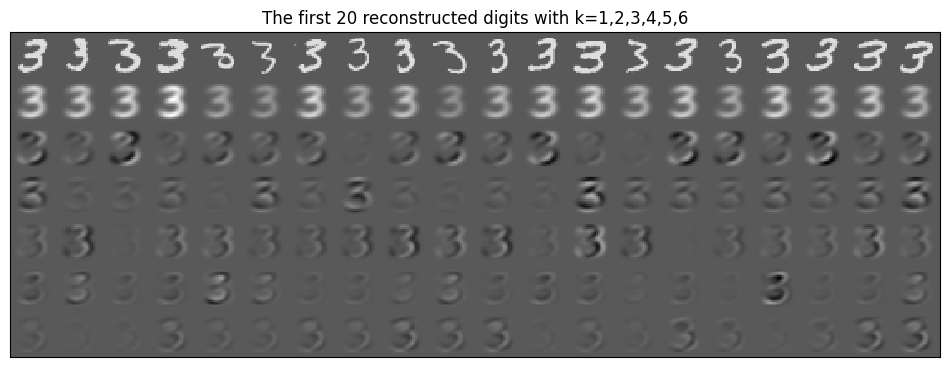

In [23]:
N = 20 # number of digits to show
digit_to_show = 3
D = X[:, y==digit_to_show]
q = np.arange(0, 6)
U, E, VT = svd(D, full_matrices = False)
M = np.array(D)[:, 0:N] # take the first 20 digits as the first row of the montage
for i, r in enumerate(q):
    Dq_th = E[r] * U[:, r].reshape(-1,1) @ VT[r, :].reshape(1,-1)
    M = np.c_[M, Dq_th[:, :N]]

plt.figure(figsize = (12, 12))
plt.imshow(montage(M, len(q)+1, N), cmap = 'gray', interpolation = 'nearest')
plt.xticks([])
plt.yticks([])
plt.title('The first %d reconstructed digits with k=1,2,3,4,5,6' % (N))
plt.show()

觀察 U 矩陣：因應 D 矩陣的結構關係，其 SVD 的 U 矩陣裡的每一行 $\underline{u}_i$ 與數字的大小相同，值得觀察其長相。當然也可以觀察看看此時的 V 矩陣的每一行長甚麼樣子？

注意：若原始圖形為人臉，則 U 矩陣的每一行 $\underline{u}_i$ 就是所謂的 eigenface，值得觀察其長相。

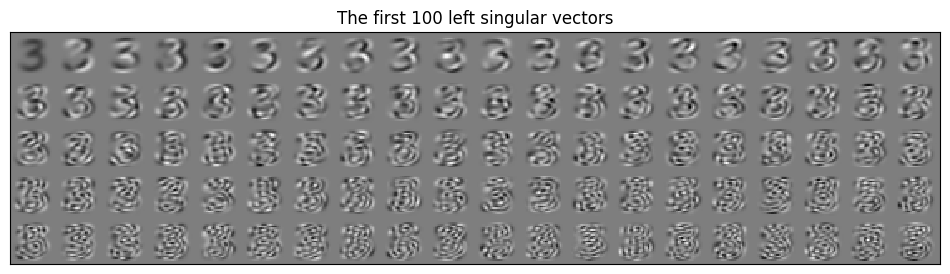

In [25]:
m, n = 5, 20
N = m * n
U, E, VT = svd(D, full_matrices = False)
# M = VT[:N, :]
M = U[:,:N]

plt.figure(figsize = (12, 12))
plt.imshow(montage(M, 5, 20), cmap = 'gray', interpolation = 'nearest')
plt.xticks([])
plt.yticks([])
plt.title('The first %d left singular vectors' % N)
plt.show()